## Statistical Forecasting on Synthetic Data

<br><br>

This notebook covers some statistical forecasting on synthetic data. This forecasting can later be compared with machine learning models forecasting

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### Timeseries plotting function & synthetic data generation

In [16]:
def plot_series(time, series, format="-", start=0, end=None):
    """
        Time: Array of ints - Contains time steps
        series: Array of ints - Contains measurements of each step
        format: line style plotting
        start: first time step to plot
        end: last time step to plot
    """
    plt.figure(figsize=(10,6))
    
    if type(series) is tuple:
        for series_num in series:
            plt.plot(time[start:end], series_num[start:end], format)
    else:
        plt.plot(time[start:end], series[start:end], format)
        
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid("True")
    plt.show()

In [3]:
def trend(time, slope=0):
    """
    Generates synthetic data that follows a straight line given a slope value.

    Args:
      time (array of int) - contains the time steps
      slope (float) - determines the direction and steepness of the line

    Returns:
      series (array of float) - measurements that follow a straight line
    """

    # Compute the linear series given the slope
    series = slope * time

    return series

def seasonal_pattern(season_time):
    """
    Just an arbitrary pattern, you can change it if you wish
    
    Args:
      season_time (array of float) - contains the measurements per time step

    Returns:
      data_pattern (array of float) -  contains revised measurement values according 
                                  to the defined pattern
    """

    # Generate the values using an arbitrary pattern
    data_pattern = np.where(season_time < 0.4,
                    np.cos(season_time * 2 * np.pi),
                    1 / np.exp(3 * season_time))
    
    return data_pattern

def seasonality(time, period, amplitude=1, phase=0):
    """
    Repeats the same pattern at each period

    Args:
      time (array of int) - contains the time steps
      period (int) - number of time steps before the pattern repeats
      amplitude (int) - peak measured value in a period
      phase (int) - number of time steps to shift the measured values

    Returns:
      data_pattern (array of float) - seasonal data scaled by the defined amplitude
    """
    
    # Define the measured values per period
    season_time = ((time + phase) % period) / period

    # Generates the seasonal data scaled by the defined amplitude
    data_pattern = amplitude * seasonal_pattern(season_time)

    return data_pattern

def noise(time, noise_level=1, seed=None):
    """Generates a normally distributed noisy signal

    Args:
      time (array of int) - contains the time steps
      noise_level (float) - scaling factor for the generated signal
      seed (int) - number generator seed for repeatability

    Returns:
      noise (array of float) - the noisy signal
    """

    # Initialize the random number generator
    rnd = np.random.RandomState(seed)

    # Generate a random number for each time step and scale by the noise level
    noise = rnd.randn(len(time)) * noise_level
    
    return noise

### Generate synthetic data

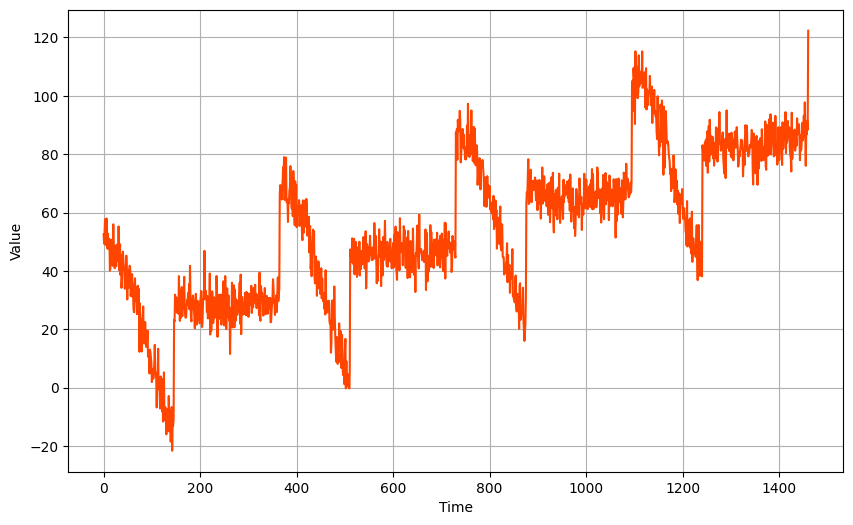

In [6]:
time = np.arange(4*365+1, dtype="float32")
baseline = 10
amplitude = 40
slope = 0.05
noise_level = 5

# Create the series
series = baseline + trend(time, slope) + seasonality(time, period=365, amplitude=amplitude)
# Update with noise
series += noise(time, noise_level, seed=42)
# Plot the results
plot_series(time, series)

#### Split the dataset

In [7]:
split_time = 1000
time_train = time[:split_time]
x_train = series[:split_time]

time_valid = time[split_time:]
x_valid = series[split_time:]

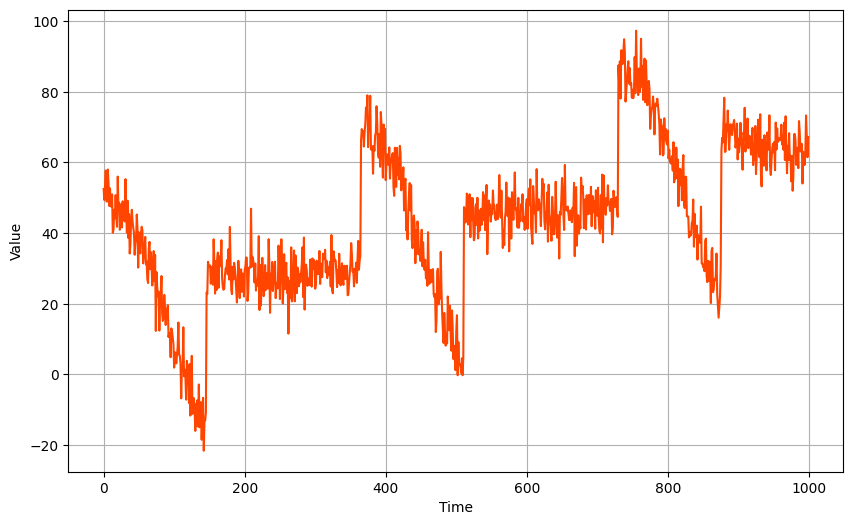

In [9]:
plot_series(time_train, x_train)

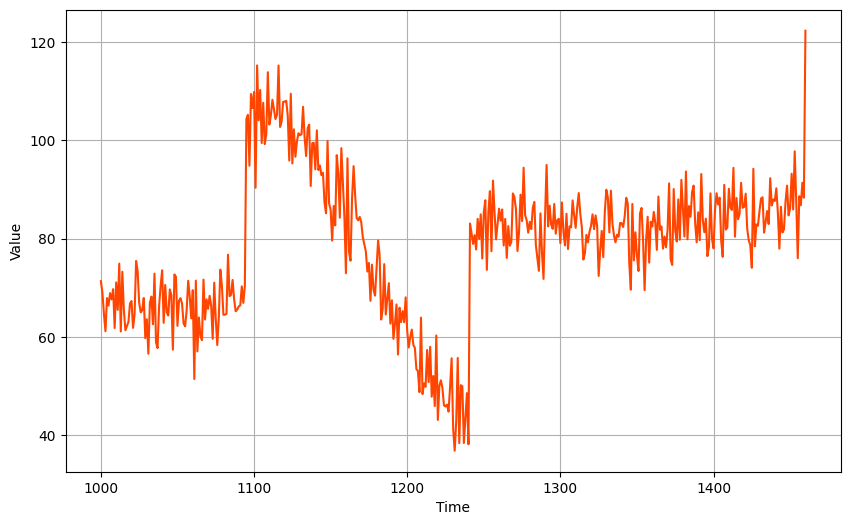

In [10]:
plot_series(time_valid, x_valid)

### Naive Forecast

In [13]:
naive_forecast = series[split_time-1:-1]

time_step = 100
print(f"Ground truth at time step {time_step}: {x_valid[time_step]}")
print(f'Prediction at time step {time_step + 1}: {naive_forecast[time_step + 1]}')

Ground truth at time step 100: 109.84197998046875
Prediction at time step 101: 109.84197998046875


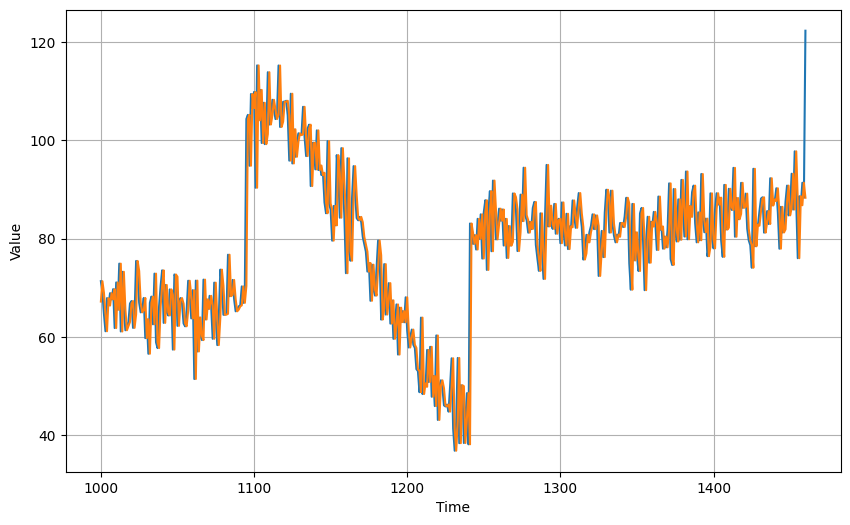

In [18]:
plot_series(time_valid, (x_valid, naive_forecast))

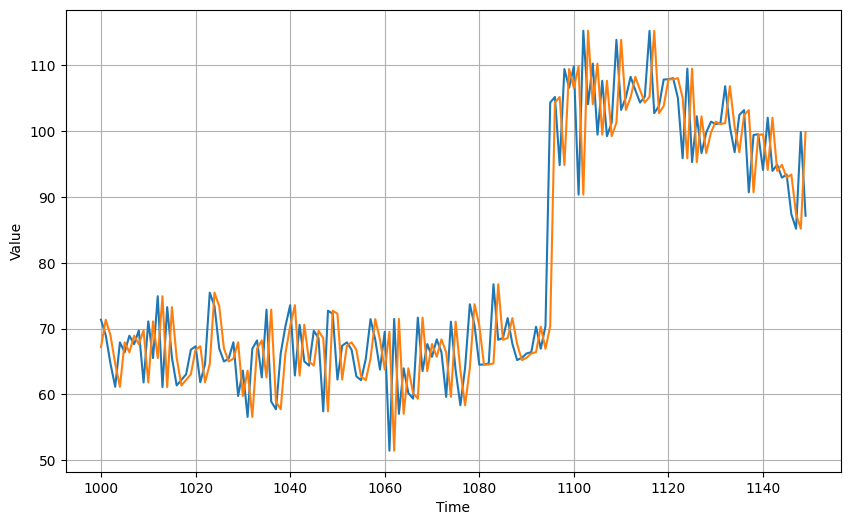

In [17]:
plot_series(time_valid, (x_valid, naive_forecast), start=0, end=150)

#### Computing metrics

In [21]:
mse = tf.keras.metrics.mse(x_valid, naive_forecast).numpy()
mae = tf.keras.metrics.mae(x_valid, naive_forecast).numpy()

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 61.82753372192383
Mean Absolute Error: 5.93790864944458


### Moving Average forecasting

<br>
One technique you can use is to do a moving average. This sums up a series of time steps and the average will be the prediction for the next time step. For example, the average of the measurements at time steps 1 to 10 will be the forecast for time step 11, then the average for time steps 2 to 11 will be the forecast for time step 12, and so on.

The function below does the moving average for the entire `series`. It takes a `window_size` argument to indicate the number of time steps to consider when computing the mean.

In [22]:
def moving_average_forecast(series, window_size):
    forecast = []
    for time in range(len(series) - window_size):
        forecast.append(series[time:time + window_size].mean())
    forecast = np.array(forecast)
    return forecast

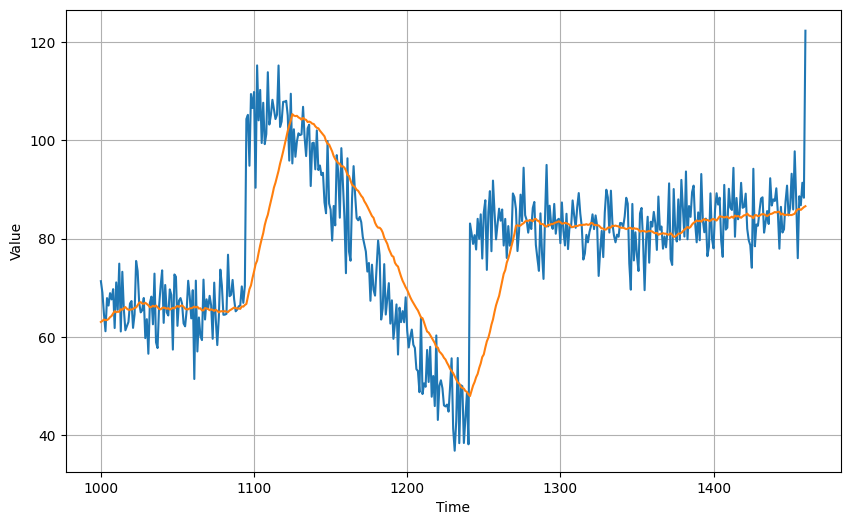

In [23]:
# Generate the moving average forecast
moving_avg = moving_average_forecast(series, 30)[split_time - 30:]
plot_series(time_valid, (x_valid, moving_avg))

In [25]:
# Compute the metrics
print("Mean squared error:", tf.keras.metrics.mse(x_valid, moving_avg).numpy())
print("Mean absolute error: ", tf.keras.metrics.mae(x_valid, moving_avg).numpy())

Mean squared error: 106.674576
Mean absolute error:  7.142419


### Differencing

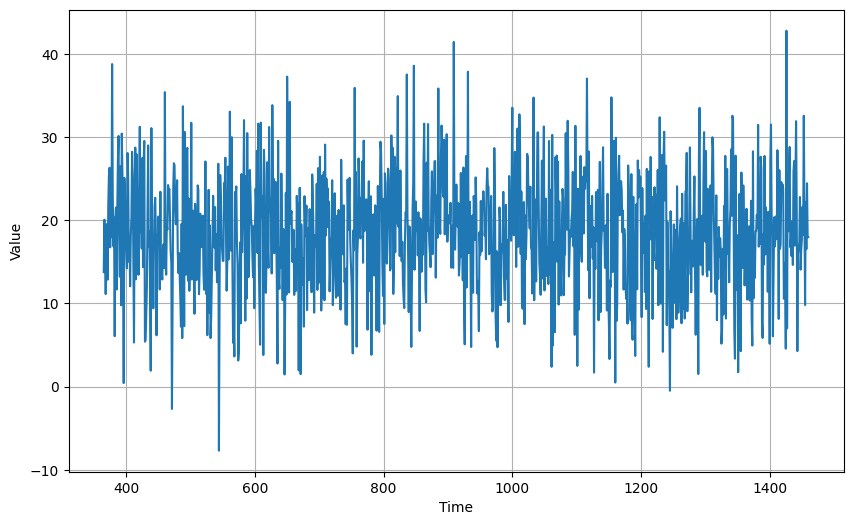

In [27]:
diff_series = (series[365:] - series[:-365])
diff_time = time[365:]
plot_series(diff_time, diff_series)

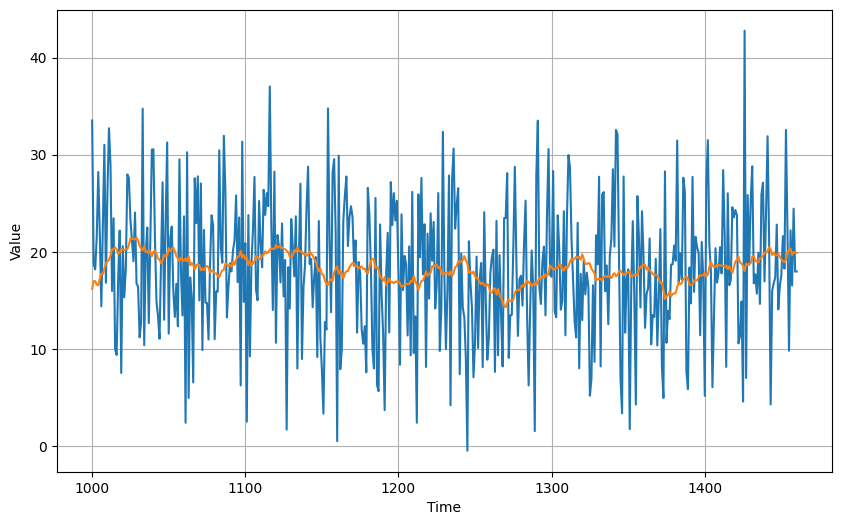

In [28]:
diff_moving_avg = moving_average_forecast(diff_series, 30)
diff_moving_avg = diff_moving_avg[split_time-365-30:]
diff_series = diff_series[split_time-365:]
plot_series(time_valid, (diff_series, diff_moving_avg))

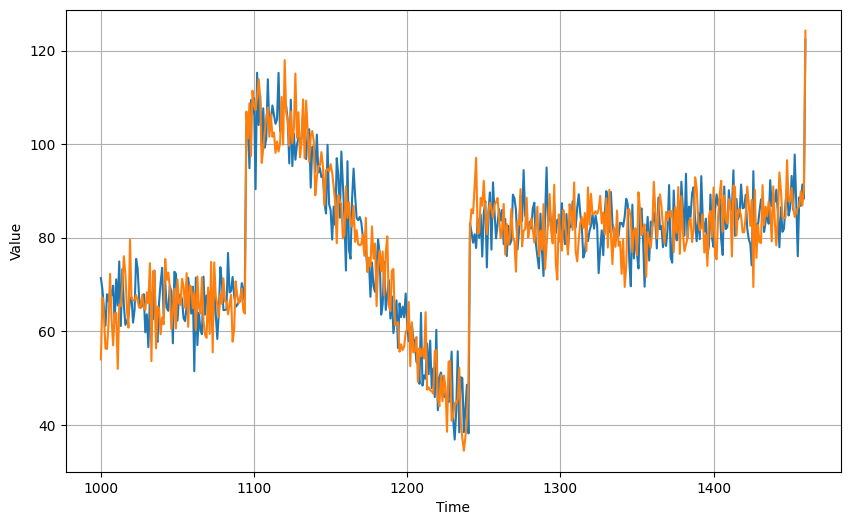

In [29]:
# Add the trend and seasonality from the original series
diff_moving_avg_plus_past = series[split_time - 365:-365] + diff_moving_avg

# Plot the results
plot_series(time_valid, (x_valid, diff_moving_avg_plus_past))

### Smoothing

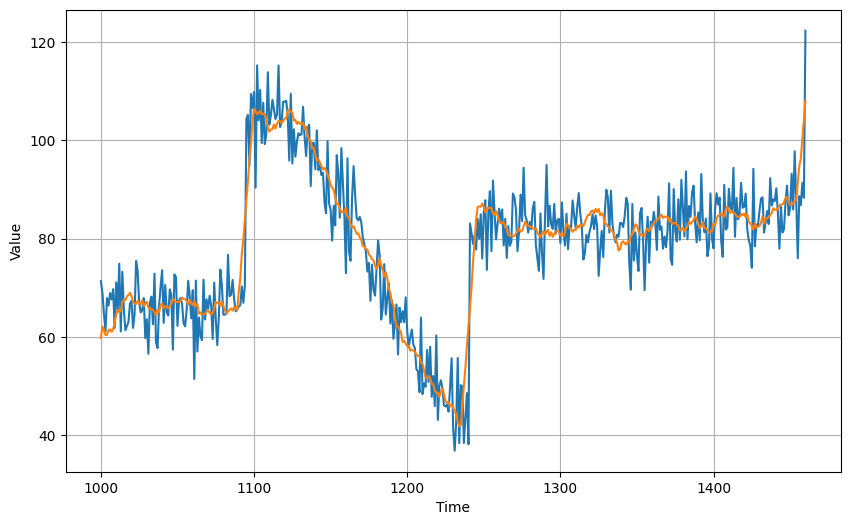

In [30]:
diff_moving_avg_plus_smooth_past = moving_average_forecast(series[split_time - 370:-359], 11) + diff_moving_avg
plot_series(time_valid, (x_valid, diff_moving_avg_plus_smooth_past))

In [31]:
 # Compute the metrics
print(tf.keras.metrics.mse(x_valid, diff_moving_avg_plus_smooth_past).numpy())
print(tf.keras.metrics.mae(x_valid, diff_moving_avg_plus_smooth_past).numpy())

34.315723
4.605329
